In [1]:
import pandas as pd

Now loading the csv file

In [2]:
data = pd.read_csv('train.csv')

Checking if the file is properly loaded or not

In [3]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print(data.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


Analyzing the data's behaviour

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Looking for missing values


In [6]:
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Filling up missing values


In [7]:
data['Age'] = data['Age'].fillna(data['Age'].mean())
data['Cabin'] = data['Cabin'].fillna(data['Cabin'].mode()[0])
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Visualization

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

************************* Survived People represented by 1 ********************************* 



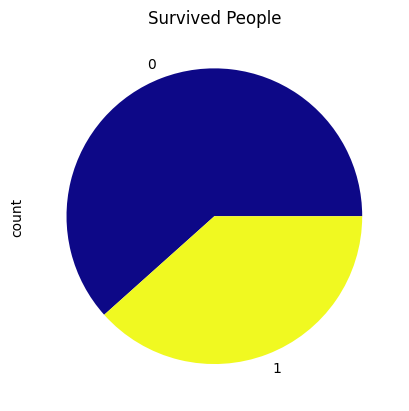

In [9]:
print("************************* Survived People represented by 1 ********************************* \n")
data['Survived'].value_counts().plot(kind = "pie", cmap = "plasma")
plt.title("Survived People")
plt.show()

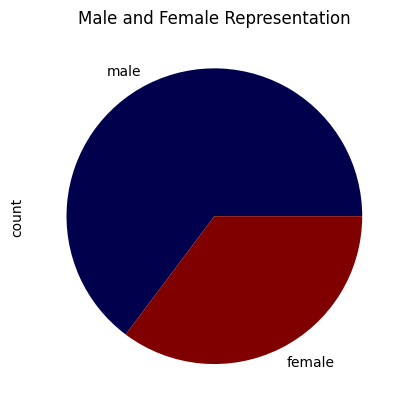

In [10]:
data['Sex'].value_counts().plot(kind = "pie", cmap = "seismic")
plt.title("Male and Female Representation")
plt.show()

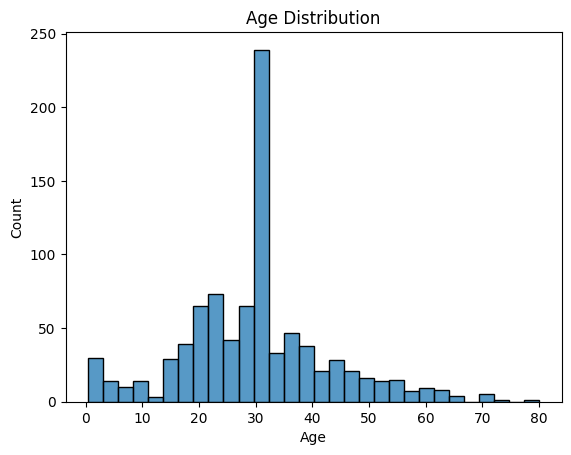

In [11]:
sns.histplot(data['Age'])
plt.title("Age Distribution")
plt.show()

# Feature Engineering
Adding Parch and SibSp to make a columns Family size

In [12]:
data['FamilySize'] = data['Parch'] + data['SibSp']

# Feature Selection
Dropping the unwanted columns


In [13]:
data = data.drop(columns = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch'], axis = 1)


Checking either the columns are dropped or not

In [14]:
print(data.columns)

Index(['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize'], dtype='object')


Converting the gender and embarked columns in 0 and 1

In [15]:
data['Sex']= data['Sex'].map({'male': 0, 'female': 1})
data['Embarked'] = data['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# HEATMAP For Seeing The Relationship


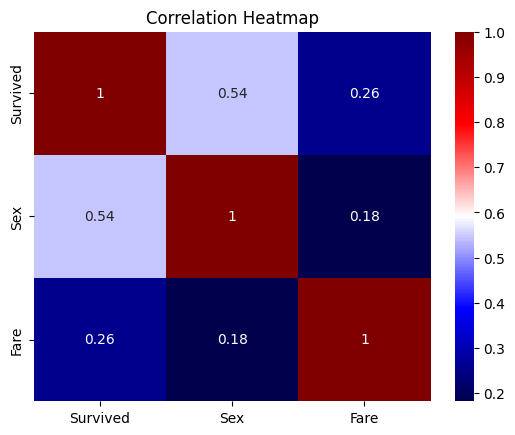

In [16]:
sns.heatmap(data[["Survived", "Sex", "Fare"]].corr(), annot = True, cmap = 'seismic')
plt.title("Correlation Heatmap")
plt.show()

<Axes: >

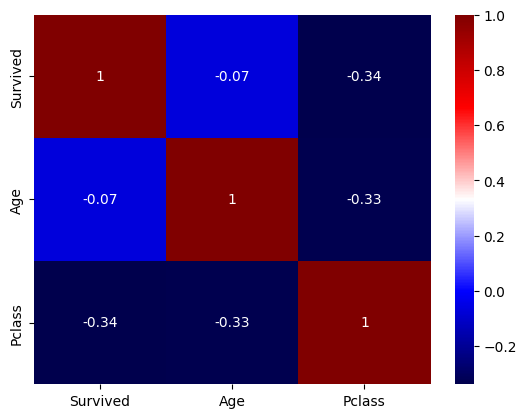

In [17]:
sns.heatmap(data[["Survived", "Age", "Pclass"]].corr(), annot = True, cmap = 'seismic')

# Importing Libraries

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



# Splitting Data
Splitting data into two parts

In [19]:
from sklearn.model_selection import train_test_split
y = data['Survived']
X = data.drop(columns = ['Survived'], axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


# Scaling

In [20]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Function To Calculate Accuracy

In [21]:
def calculate_accuracy(model, X_test, y_test):
  y_pred = model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  return accuracy

# MODEL IMPLEMENTATION
1. LOGISTIC REGRESSION

In [22]:
model = LogisticRegression()
model.fit(X_train, y_train)
accuracy = calculate_accuracy(model, X_test, y_test)
print(f"\n Accuracy of Logistic Regression: {accuracy} \n")
print(classification_report(y_test, model.predict(X_test)))


 Accuracy of Logistic Regression: 0.7988826815642458 

              precision    recall  f1-score   support

           0       0.81      0.86      0.83       105
           1       0.78      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



2. RANDOM FOREST

In [23]:
random_forest = RandomForestClassifier()
random_forest.fit(X_train, y_train)
accuracy = calculate_accuracy(random_forest, X_test, y_test)
print(f"\n Accuracy of Random Forest: {accuracy} \n")
print(classification_report(y_test, random_forest.predict(X_test)))


 Accuracy of Random Forest: 0.8212290502793296 

              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



3. KNN


In [24]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
accuracy = calculate_accuracy(knn, X_test, y_test)
print(f"\n Accuracy of KNN: {accuracy} \n")
print(classification_report(y_test, knn.predict(X_test)))


 Accuracy of KNN: 0.8044692737430168 

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



4. SVC

In [25]:
svc = SVC()
svc.fit(X_train, y_train)
accuracy = calculate_accuracy(svc, X_test, y_test)
print(f"\n Accuracy of SVM: {accuracy} \n")
print(classification_report(y_test, svc.predict(X_test)))


 Accuracy of SVM: 0.8156424581005587 

              precision    recall  f1-score   support

           0       0.81      0.90      0.85       105
           1       0.84      0.69      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.81       179



5. XG BOOST

In [26]:
xg_boost = xgb.XGBClassifier()
xg_boost.fit(X_train, y_train)
accuracy = calculate_accuracy(xg_boost, X_test, y_test)
print(f"\n Accuracy of XG Boost: {accuracy} \n")
print(classification_report(y_test, xg_boost.predict(X_test)))


 Accuracy of XG Boost: 0.7932960893854749 

              precision    recall  f1-score   support

           0       0.82      0.83      0.82       105
           1       0.75      0.74      0.75        74

    accuracy                           0.79       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.79      0.79      0.79       179



By implementing several models i reached the conclusion that ***Random Forest Model*** is the best Model for this dataset